In [1]:
# Import the pyKasso and numpy packages
import pykasso as pk
import numpy as np
import os
import matplotlib.pyplot as plt
import CFPy as cfpy

In [2]:
# Create a pyKasso application
app = pk.pykasso()

# Declare the grid parameters
grid_parameters = {
    'x0': 0, 'y0': 0, 'z0': 0,
    'nx': 100, 'ny': 80, 'nz': 20,
    'dx': 10, 'dy': 10, 'dz': 10,
}

# Declare the project parameters
app.new_project(name='example_02', grid_parameters=grid_parameters)

# Declare some options for the visualization
app.visualizer.notebook = True
extent = app.project.grid.extent
imshow_options = {'extent': extent}

### Notes
- in the documentation / the [example](https://github.com/randlab/pyKasso/blob/master/notebooks/paper/example_02.ipynb), there are information on water table and bedrock that are given to pyKasso
- we don't care for that here, so we use simple placeholders

In [3]:
bedrock = np.zeros((grid_parameters["nx"], grid_parameters["ny"]))
water_table = np.ones((grid_parameters["nx"], grid_parameters["ny"])) * 100.

In [4]:
# Declare the model parameters
model_parameters = {
    'sks' : {
        'seed' : 123,
    },
    'domain' : {
        'bedrock' : bedrock,
        'water_table' : water_table
    },
    'outlets' : {
        'data' : [[990, 400, 10]],
        'number' : 1,
        'subdomain': 'bedrock_phreatic',
    },
    'inlets' : {
        'data' : [[10, 200], [10, 600]],
        'number': 2
    },
    'fractures' : {
        'generate': {
            'family_01': {
                'density'      : 0.00005,
                'orientation'  : 135,
                'dip'          : 90,
                'length'       : 300,
            },
            'family_02': {
                'density'      : 0.00005,
                'orientation'  : 45,
                'dip'          : 90,
                'length'       : 500,
            }
        }
    },
}

In [5]:
app.model.generate(model_parameters=model_parameters)

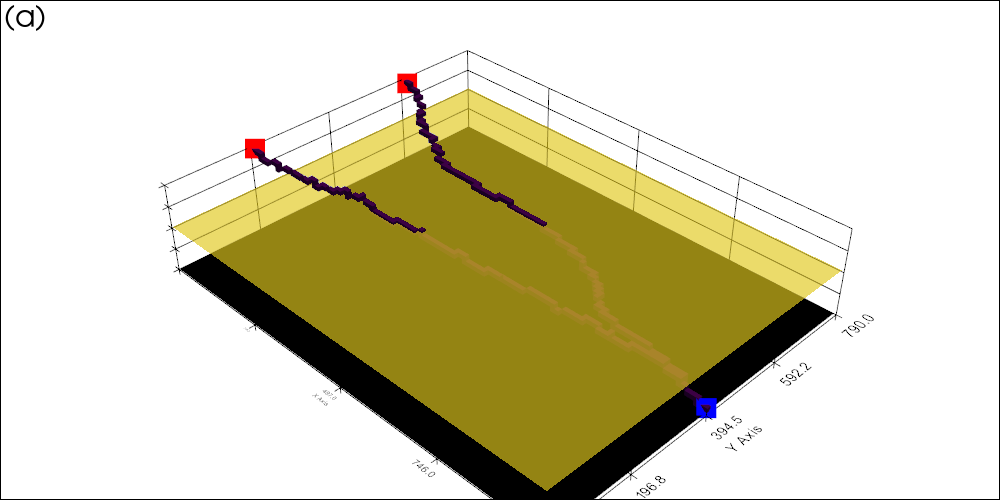

In [6]:
# Basic settings for pv_show() 
settings = {
    'mask_values': [0], # To mask the geology
    'surfaces_options' : { # To see the top bedrock and water level
        'bedrock' : {'opacity':1, 'cmap': 'copper'},
        'water_table' : {},
    },
    'inlets_options' : {},
    'outlets_options' : {},
    'show_scalar_bar' : False,
}

# To add the (a) and (b) labels on the subfigures
font_size = 12
settings_1 = settings.copy()
settings_1['text_options'] = {'text' : '(a)', 'font_size': font_size}
settings_2 = settings.copy()
settings_2['text_options'] = {'text' : '(b)', 'font_size': font_size}

# To select the two last simulations
last_simulations = app.project.get_last_simulations(2)

# File name to save the figure
figfilename = os.path.join('fig', 'example_02_iso_vs_ani.png') 

# Generating the 3D plot
app.visualizer.pv_show(
    simulations=last_simulations,
    features=['karst'],
    settings=[settings_1, settings_2],
    cpos=[1, -1, 1],
    window_size=(1000, 500),
    zoom=1.4,
    savefig=False,
    filename=figfilename,
)

## pyKasso Update / Improvement
- pyKasso can _voxelize_ the karst network
- after that, we get a discrete cell-by-cell network that we can also use in `CFPy`
- we are missing, however, the node elevation data
- we created a small addition in `pyKasso.sks.SKS._voxelize_karst_network`
- now, `SKS` has an attribute `node_elev_arr` that includes the cell-by-cell _voxelized_ node elevations we can directly use for `CFPy`

(100, 80, 20)
(80, 100, 20)
(100, 80, 20)
(80, 100, 20)


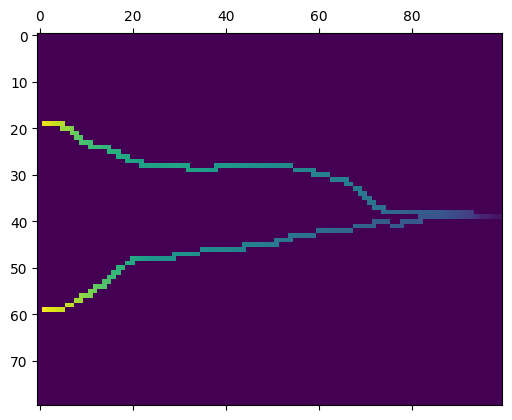

In [ ]:
network = np.array(app.model.maps['karst'][0]) # shape (nx, ny, nz) == (ncol, nrow, nlay)
print(network.shape)
network = np.moveaxis(network, 1, 0)
print(network.shape)

elevations = app.model.node_elev_arr
print(elevations.shape)
elevations = np.moveaxis(elevations, 1, 0)
print(elevations.shape)

# "project" the nodes onto the plane
network = np.max(network, axis=-1)[::-1, :]
# perform the same transform with elevs
elevations = np.max(elevations, axis=-1)[::-1, :]

plt.matshow(network * elevations)


Always visually check the validated network for structuralcorrectness! 
i.e., whether branches are correctly isolated or ifthey got connected during processing.


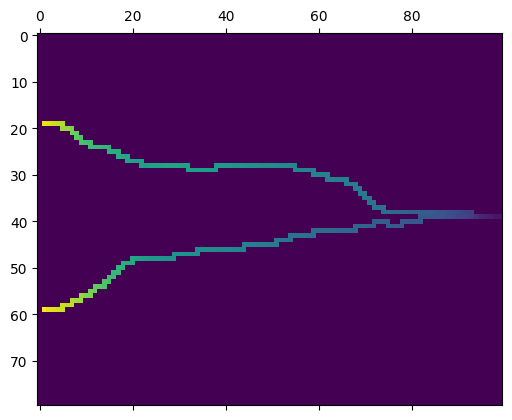

In [9]:
# use a CFPy elevation-enabled validator to validate the network

# validate the network from pyKasso
validator = cfpy.preprocessing.GeneralValidator(network=network, elevations=elevations)
valid_network = validator.validate_network_elevations()

# nrows = catchment.get_ynum()
# ncols = catchment.get_xnum()

# validator.generate_nbr(nrows=nrows, ncols=ncols, nlays=1, layer_elevations=[[1000.], [0.]])

# plot the network
plt.matshow(valid_network)